In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from os.path import join
from scipy.signal import butter, lfilter 
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import utils

from multitaper_spectogram_python import multitaper_spectrogram
from scipy.signal import spectrogram, chirp, welch
from scipy.integrate import trapezoid

import pywt

In [9]:
ROOT_PATH_TRAIN = join('..','Data','train')
X_raw = np.load(join(ROOT_PATH_TRAIN, 'data_0.npy'))
y = np.load(join(ROOT_PATH_TRAIN, 'target_0.npy'))

In [10]:
X_raw.shape, y.shape

((5, 7712740), (5, 15425))

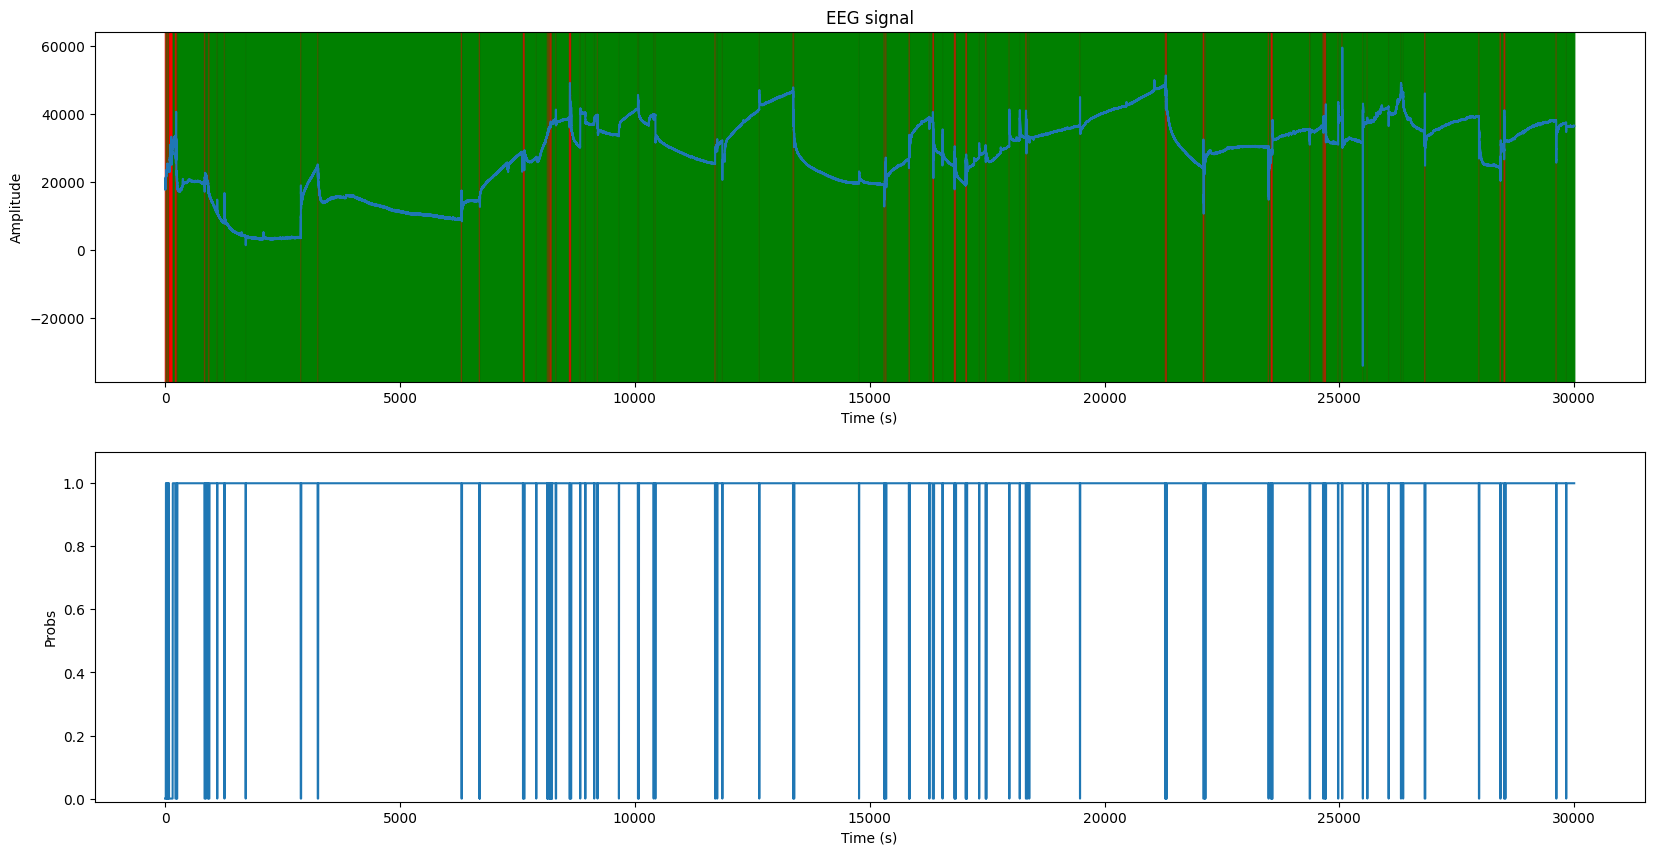

In [11]:
utils.plot_predictions_and_signal(y, X_raw, start_time=0, stop_time=30000, channel_to_plot=0)

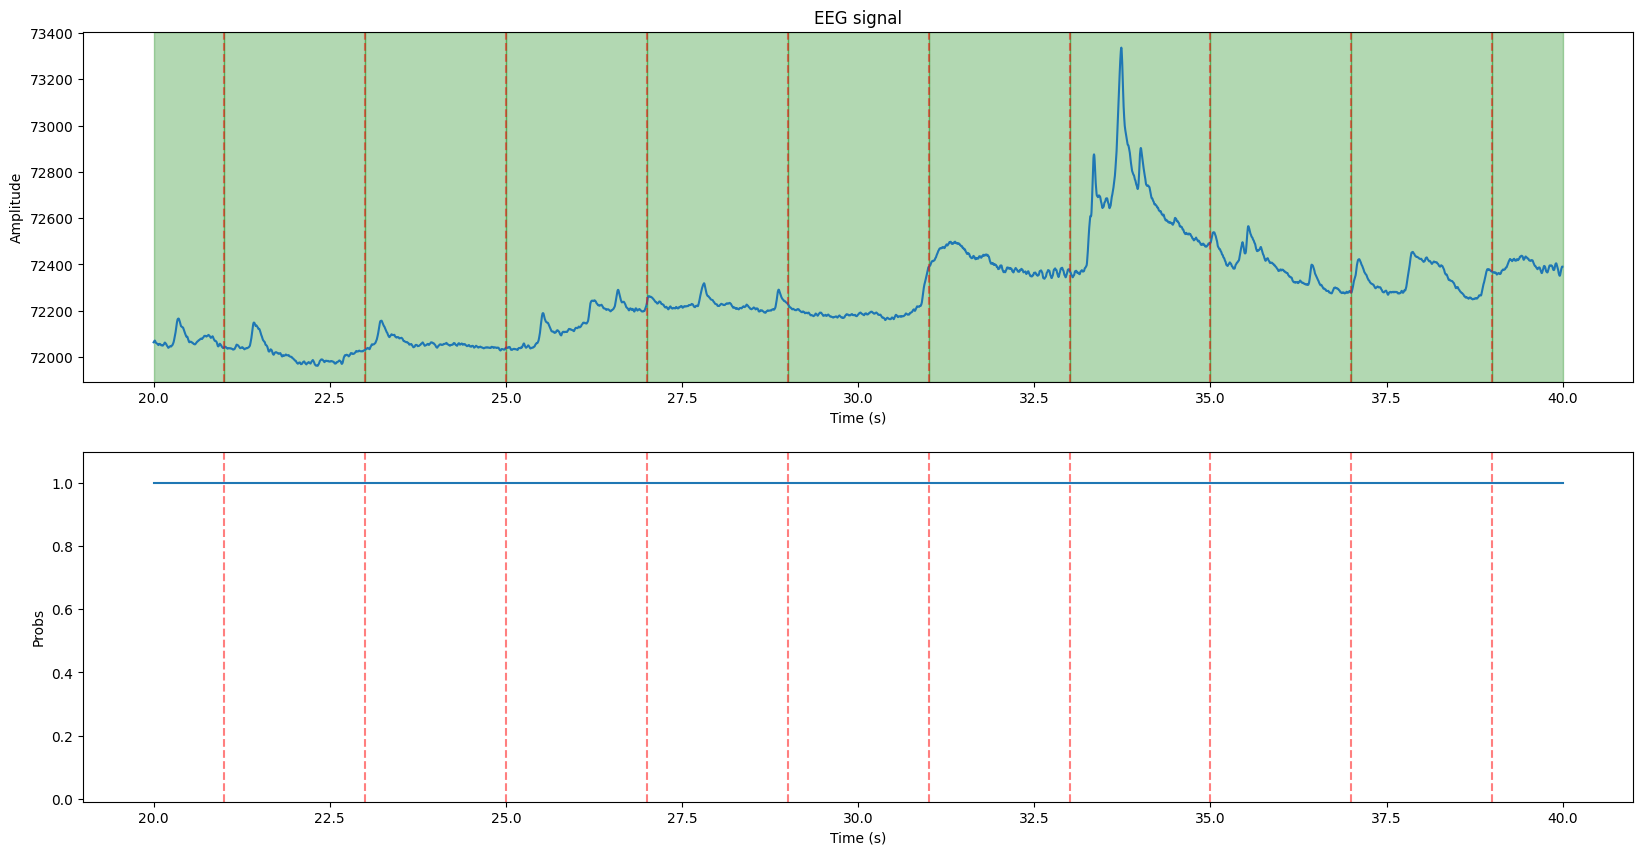

In [12]:
X_filtered = utils.butter_lowpass_filter(X_raw, cutoff=20, fs=250, order=3)
utils.plot_predictions_and_signal(y, X_filtered, start_time=20, stop_time=40, channel_to_plot=1)

# Frequency domain features

In [13]:
def plot_spectrogram(X, start_time = None, stop_time = None, channel = 0, fs = 250):
    # Set spectrogram params
    fs = fs  # Sampling Frequency
    frequency_range = [0, 60]  # Limit frequencies from 0 to 25 Hz
    time_bandwidth = 4  # Set time-half bandwidth
    num_tapers = 7  # Set number of tapers (optimal is time_bandwidth*2 - 1)
    window_params = [4, 1]  # Window size is 4s with step size of 1s
    min_nfft = 0  # No minimum nfft
    detrend_opt = 'constant'  # detrend each window by subtracting the average
    multiprocess = True  # use multiprocessing
    n_jobs = 3  # use 3 cores in multiprocessing
    weighting = 'unity'  # weight each taper at 1
    plot_on = True  # plot spectrogram
    return_fig = False  # do not return plotted spectrogram
    clim_scale = False # do not auto-scale colormap
    verbose = True  # print extra info
    xyflip = False  # do not transpose spect output matrix
        
    start_index = int(start_time * fs)
    end_index = int(stop_time * fs)


    # Compute the multitaper spectrogram
    spect, stimes, sfreqs = multitaper_spectrogram(X_raw[channel][start_index : end_index], fs, frequency_range, time_bandwidth, num_tapers, window_params, min_nfft, detrend_opt, multiprocess, n_jobs,
                                                weighting, plot_on, return_fig, clim_scale, verbose, xyflip)
    
    return spect, stimes, sfreqs

Multitaper Spectrogram Properties: 
     Spectral Resolution: 2.0Hz
     Window Length: 4.0s
     Window Step: 1.0s
     Time Half-Bandwidth Product: 4
     Number of Tapers: 7
     Frequency Range: 0-60Hz
     NFFT: 1024
     Detrend: constant


 Multitaper compute time: 1.94 seconds


c:\Users\Marti\OneDrive - CentraleSupelec\CS courses\S9\ML\Competition\EEG_signals_quality_analysis\Notebooks\multitaper_spectogram_python.py:201: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


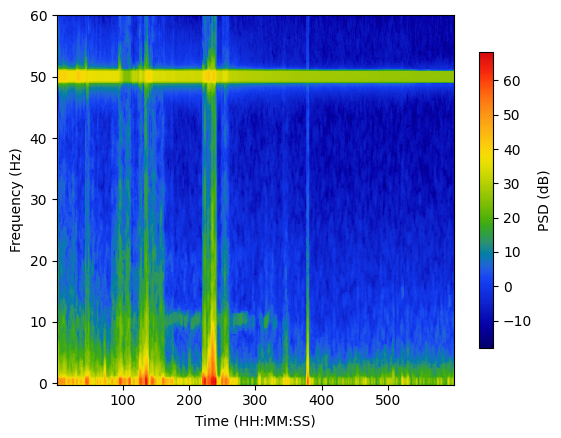

In [14]:
_, _, _ = plot_spectrogram(X_raw, 0, 600, channel = 0, fs = 250)

In [15]:
X_window = utils.reshape_array_into_windows(X_raw, sample_rate=250, window_duration_in_seconds=2)
X = X_window[0, 0]

In [16]:
X_window.shape

(5, 15425, 500)

In [17]:
fs = 250
freqs, psd = welch(X, fs, nperseg=512)

c:\Users\Marti\OneDrive - CentraleSupelec\CS courses\S9\ML\Competition\EEG_signals_quality_analysis\Env\Lib\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 512 is greater than input length  = 500, using nperseg = 500
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


In [18]:
freqs.shape, psd.shape

((251,), (251,))

In [19]:
def plot_window_spectrogram(X, fs = 250):
    # Set spectrogram params
    fs = fs  # Sampling Frequency
    frequency_range = [0, 60]  # Limit frequencies from 0 to 25 Hz
    time_bandwidth = 3  # Set time-half bandwidth
    num_tapers = 5  # Set number of tapers (optimal is time_bandwidth*2 - 1)
    window_params = [1.5, 0.5]  # Window size is 4s with step size of 1s
    min_nfft = 0  # No minimum nfft
    detrend_opt = 'constant'  # detrend each window by subtracting the average
    multiprocess = True  # use multiprocessing
    n_jobs = 3  # use 3 cores in multiprocessing
    weighting = 'unity'  # weight each taper at 1
    plot_on = True  # plot spectrogram
    return_fig = False  # do not return plotted spectrogram
    clim_scale = False # do not auto-scale colormap
    verbose = True  # print extra info
    xyflip = False  # do not transpose spect output matrix


    # Compute the multitaper spectrogram
    spect, stimes, sfreqs = multitaper_spectrogram(X, fs, frequency_range, time_bandwidth, num_tapers, window_params, min_nfft, detrend_opt, multiprocess, n_jobs,
                                                weighting, plot_on, return_fig, clim_scale, verbose, xyflip)
    
    return spect, stimes, sfreqs

Multitaper Spectrogram Properties: 
     Spectral Resolution: 4.0Hz
     Window Length: 1.5s
     Window Step: 0.5s
     Time Half-Bandwidth Product: 3
     Number of Tapers: 5
     Frequency Range: 0-60Hz
     NFFT: 512
     Detrend: constant


 Multitaper compute time: 0.01 seconds


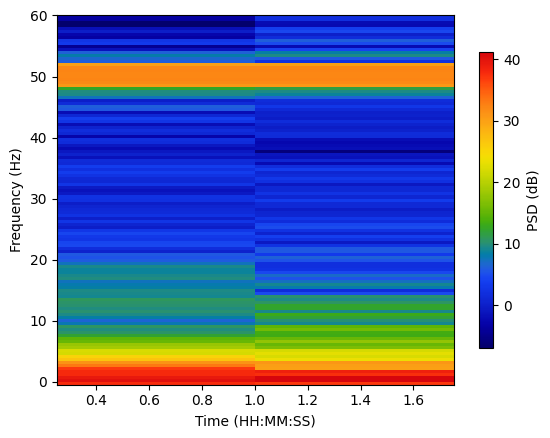

In [20]:
spect, stimes, sfreqs = plot_window_spectrogram(X)

In [21]:
spect.shape, stimes.shape, sfreqs.shape


((123, 2), (2,), (123,))

In [22]:
def bandpower (psd, freqs, fmin, fmax):
    idx_band = np.logical_and(freqs >= fmin, freqs <= fmax)
    if psd.ndim > 1:
        values = list()
        for i in range(psd.shape[-1]):
            bp = trapezoid(psd[idx_band, i], freqs[idx_band])
            values.append(bp)
        value = np.mean(values)
    else:
        value = trapezoid(psd[idx_band], freqs[idx_band]) 
        
    return round(value, 2)

In [23]:
def compute_bandpower(psd, freqs):
    return (
        bandpower(psd, freqs, 0, 4),
        bandpower(psd, freqs, 4, 8),
        bandpower(psd, freqs, 8, 13),
        bandpower(psd, freqs, 13, 22),
        bandpower(psd, freqs, 22, 60)
    )

In [24]:
compute_bandpower(psd, freqs)

(20840.26, 209.94, 33.34, 30.02, 5816.83)

In [25]:
compute_bandpower(spect, sfreqs)

(21433.4, 322.1, 60.67, 49.94, 5906.14)

# Time domain features

In [26]:
import pywt

# Choose a wavelet, e.g., 'morl' for Morlet wavelet
wavelet = 'morl'
fs = 250

# Perform CWT, scales control the frequency resolution
scales = np.arange(1, 50)
coefficients, frequencies = pywt.cwt(X, scales, wavelet, sampling_period=1/fs)

# Common CWT-based features
mean_coefficients = np.mean(np.abs(coefficients), axis=1)  # Mean power at each scale
max_coefficients = np.max(np.abs(coefficients), axis=1)    # Max power at each scale
entropy_coefficients = -np.sum(coefficients * np.log(np.abs(coefficients) + 1e-10), axis=1)

In [27]:
mean_coefficients

array([  29.87967 ,   41.161636,  121.01216 ,  255.81691 ,  216.60612 ,
        197.30063 ,  247.03775 ,  300.18466 ,  357.20163 ,  422.82254 ,
        485.76355 ,  550.674   ,  619.52747 ,  693.98676 ,  771.94305 ,
        846.0708  ,  933.91656 , 1013.2031  , 1092.171   , 1178.5823  ,
       1269.925   , 1357.895   , 1445.8933  , 1539.7002  , 1640.765   ,
       1736.6528  , 1844.4972  , 1956.2428  , 2068.1267  , 2190.7195  ,
       2292.9016  , 2397.1846  , 2512.185   , 2624.5107  , 2721.863   ,
       2839.922   , 2936.4326  , 3040.2515  , 3167.136   , 3287.138   ,
       3416.3904  , 3567.7375  , 3697.377   , 3840.9424  , 3990.08    ,
       4137.562   , 4285.7617  , 4425.549   , 4570.233   ], dtype=float32)

In [21]:
from pywt import WaveletPacket

# Initialize the wavelet packet with a specified wavelet (e.g., 'db4' for Daubechies 4)
wp = WaveletPacket(data=X, wavelet='db4', maxlevel=3)

# Extract the nodes for different decomposition levels
nodes = [node for node in wp.get_level(3, 'freq')]

# Calculate features for each node
wp_energy = [np.sum(np.square(node.data)) for node in nodes]
wp_entropy = [-np.sum(node.data * np.log(np.abs(node.data) + 1e-10)) for node in nodes]


In [22]:
wp_energy

[218782740000.0,
 17196.795,
 543213.3,
 2199621.8,
 540017.2,
 133134.02,
 4694.4707,
 5116.24]

In [28]:
X_window = utils.reshape_array_into_windows(X_filtered, sample_rate=250, window_duration_in_seconds=2)
X = X_window[0, 0]

In [29]:
utils.custom_features_window(X)

22508.50059826269

In [30]:
utils.time_domain_features_window(X)

(21800.519914722016,
 205.0934233927396,
 21595.426491329275,
 19902.44257765518,
 2611204.3172995476,
 -10.111595054098208,
 107.22988711846945)

In [31]:
utils.complexity_features_window(X)

(0.09813346409385952,
 0.007343822545249027,
 0.016966266479820802,
 0.5384166510118509)

# Merge all data

In [32]:
training_data = [(np.load(join( ROOT_PATH_TRAIN, f"data_{i}.npy")),np.load(join(ROOT_PATH_TRAIN , f"target_{i}.npy"))) for i in range(4)]

In [33]:
all_data_raw = []
all_data_filtered = []
all_targets = []

filter_cutoff = 25

for data, target in training_data:
    filtered = utils.butter_lowpass_filter(data, cutoff=filter_cutoff, fs=250, order=3)
    reshaped_data_filtered = utils.reshape_array_into_windows(filtered, sample_rate=250, window_duration_in_seconds=2)
    reshaped_data_raw = utils.reshape_array_into_windows(data, sample_rate=250, window_duration_in_seconds=2)
    targets_flatten = target.flatten()
    reshaped_data_filtered = reshaped_data_filtered.reshape((-1,reshaped_data_filtered.shape[-1]))
    reshaped_data_raw = reshaped_data_raw.reshape((-1,reshaped_data_raw.shape[-1]))
    all_data_filtered.append(reshaped_data_filtered)
    all_data_raw.append(reshaped_data_raw)
    all_targets.append(targets_flatten)

all_data_filtered = np.concatenate(all_data_filtered)
all_data_raw = np.concatenate(all_data_raw)
all_targets = np.concatenate(all_targets)

assert all_data_filtered.shape[0] == all_data_raw.shape[0] == all_targets.shape[0]
    

# Merge all features

In [34]:
create_features = False

if create_features:
    column_names = ['max_val', 
                    'min_val',
                    'amplitude',
                    'mean',
                    'variance',
                    'skewness',
                    'kurt',
                    'shannon',
                    'sampen',
                    'apen',
                    'H',
                    'mmd',
                    'delta',
                    'theta',
                    'alpha',
                    'beta',
                    'gamma'
                    ]

    df = pd.DataFrame(columns=column_names)
    max_val, min_val, amplitude, mean, variance, skewness, kurt = utils.time_domain_features_window(all_data_filtered)
    df['max_val'] = max_val
    df['min_val'] = min_val
    df['amplitude'] = amplitude
    df['mean'] = mean
    df['variance'] = variance
    df['skewness'] = skewness
    df['kurt'] = kurt
    #takes like 30 min to compute
    shannon, sampen, apen, H = utils.complexity_features_all_data(all_data_filtered)
    df['shannon'] = shannon
    df['sampen'] = sampen
    df['apen'] = apen
    df['H'] = H
    mmd = utils.custom_features_all_data(all_data_filtered)
    df['mmd'] = mmd
    #takes 1h to compile
    delta, theta, alpha, beta, gamma = utils.frequency_domain_features_all_data(all_data_raw)
    df['delta'] = delta
    df['theta'] = theta
    df['alpha'] = alpha
    df['beta'] = beta
    df['gamma'] = gamma
    
    df['target'] = all_targets
    
    df.to_csv('features.csv', index=False)
    
else:
    df = pd.read_csv('features.csv')


 Data was all zeros, no output
